# Day 3 · Notebook 2 — Unsupervised learning
### ML Bootcamp · Day 3 of 5

No labels today! In this notebook you will:
1. Group mall customers with **K-Means** *(Parts 1–2)*
2. Build a family tree of customers with **hierarchical clustering** *(Part 3)*
3. Squeeze 64-pixel images into 2 numbers with **PCA** *(Part 4)*
4. Catch a **faulty motor** with anomaly detection *(Part 5)*

> Run cells in order with **Shift + Enter**. Needs internet for the mall data. 🧠 = think about it, ✍️ = exercise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
print("Ready!")

Ready!


---
## Part 1 · Meet the mall customers
200 shoppers with their annual income (thousands of $) and a **spending score** from 1–100 given by the mall. There is **no label** — nobody has told us what types of customers exist.

In [2]:
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
mall = pd.read_csv(url)
mall = mall.rename(columns={"Annual Income (k$)": "income", "Spending Score (1-100)": "spending"})
print(mall.shape)
mall.head()

(200, 5)


,CustomerID,Gender,Age,income,spending
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


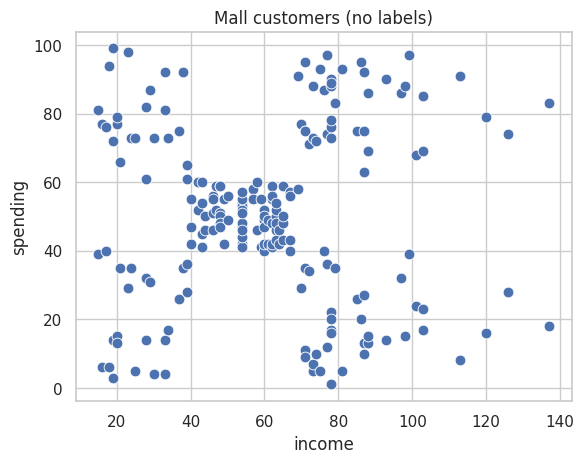

In [3]:
sns.scatterplot(data=mall, x="income", y="spending", s=60)
plt.title("Mall customers (no labels)")
plt.show()

🧠 Before running any algorithm: how many groups can **you** see?

---
## Part 2 · K-Means
We give K-Means only the two columns — **no y**. Income and spending are on similar scales (roughly 0–140 and 0–100), so we skip scaling here.

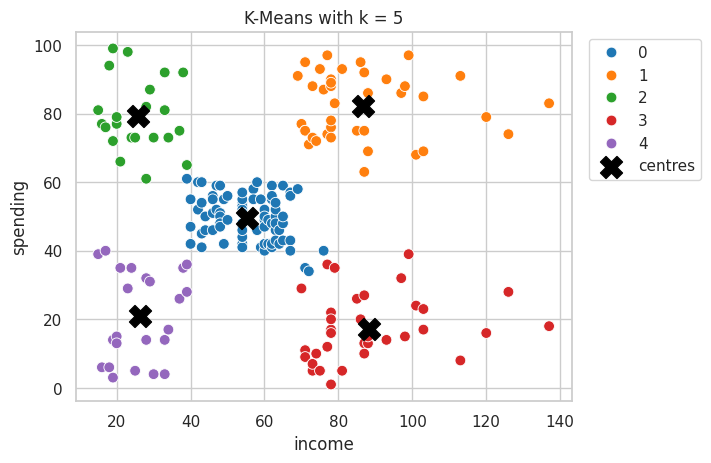

In [4]:
X = mall[["income", "spending"]].values

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
mall["cluster"] = kmeans.fit_predict(X)

sns.scatterplot(data=mall, x="income", y="spending", hue="cluster", palette="tab10", s=60)
centres = kmeans.cluster_centers_
plt.scatter(centres[:, 0], centres[:, 1], c="black", marker="X", s=250, label="centres")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("K-Means with k = 5")
plt.show()

### 2.1 Describe each group
K-Means only says "group 0, 1, 2…". **We** give the groups names by looking at their averages.

In [5]:
profile = mall.groupby("cluster").agg(customers=("income", "size"), income=("income", "mean"),
                                      spending=("spending", "mean"), age=("Age", "mean")).round(1)

def name_group(row):
    inc = "High income" if row.income > 70 else ("Low income" if row.income < 40 else "Middle income")
    spd = "high spending" if row.spending > 60 else ("low spending" if row.spending < 40 else "middle spending")
    return f"{inc}, {spd}"

profile["description"] = profile.apply(name_group, axis=1)
profile

,customers,income,spending,age,description
cluster,,,,,
0,81,55.3,49.5,42.7,"Middle income, middle spending"
1,39,86.5,82.1,32.7,"High income, high spending"
2,22,25.7,79.4,25.3,"Low income, high spending"
3,35,88.2,17.1,41.1,"High income, low spending"
4,23,26.3,20.9,45.2,"Low income, low spending"


### 2.2 How many groups? Elbow and silhouette
- **Inertia**: how spread out each group is (lower = tighter). It always goes down as k grows, so we look for the **elbow**.
- **Silhouette**: how well separated the groups are, from −1 to 1 (higher = better).

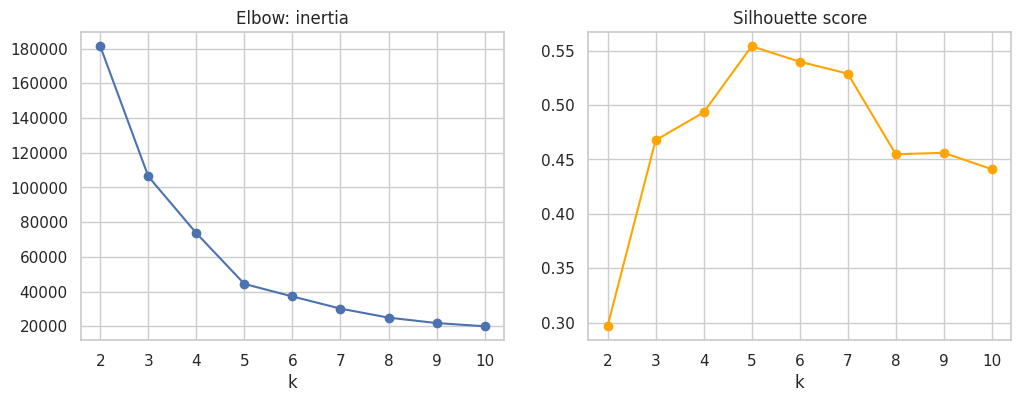

Best silhouette: k = 5 (0.554)


In [6]:
ks = range(2, 11)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inertias, marker="o"); ax[0].set_title("Elbow: inertia"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), silhouettes, marker="o", color="orange"); ax[1].set_title("Silhouette score"); ax[1].set_xlabel("k")
plt.show()

best_k = list(ks)[int(np.argmax(silhouettes))]
print(f"Best silhouette: k = {best_k} ({max(silhouettes):.3f})")

---
## Part 3 · Hierarchical clustering
Start with every customer as its own group, then keep merging the two closest groups. The **dendrogram** shows the whole family tree.

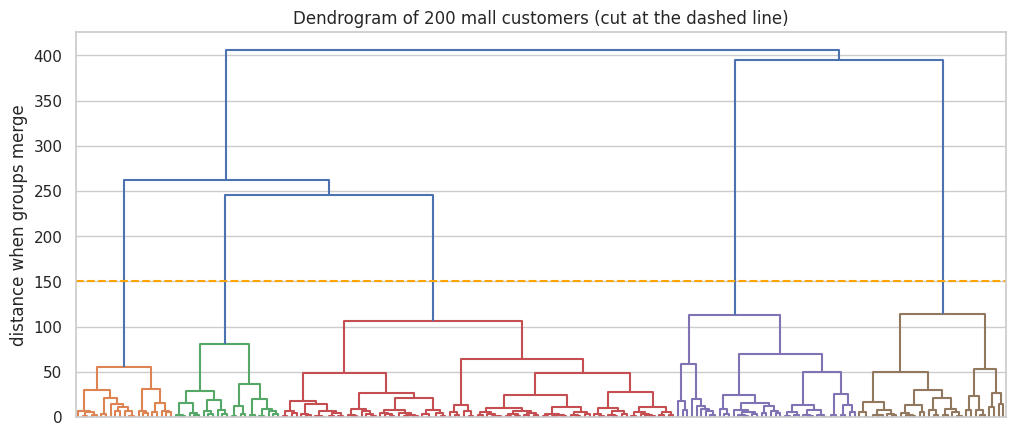

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(12, 5))
dendrogram(linkage(X, method="ward"), no_labels=True, color_threshold=150)
plt.axhline(150, color="orange", linestyle="--")
plt.title("Dendrogram of 200 mall customers (cut at the dashed line)")
plt.ylabel("distance when groups merge")
plt.show()

In [8]:
from sklearn.metrics import adjusted_rand_score

agg = AgglomerativeClustering(n_clusters=5)
mall["hier"] = agg.fit_predict(X)

print(f"Agreement with K-Means (1 = identical): {adjusted_rand_score(mall['cluster'], mall['hier']):.2f}")
pd.crosstab(mall["cluster"], mall["hier"], rownames=["K-Means"], colnames=["Hierarchical"])

Agreement with K-Means (1 = identical): 0.94


Hierarchical,0,1,2,3,4
K-Means,,,,,
0,0,81,0,0,0
1,0,0,39,0,0
2,0,1,0,21,0
3,32,3,0,0,0
4,0,0,0,0,23


🧠 Two completely different methods found almost the same five groups. That gives us confidence the groups are real, not an accident of one algorithm.

---
## Part 4 · PCA on handwritten digits
Each image is 8 × 8 = **64 pixels**, so each image is a point in 64 dimensions — impossible to draw. PCA finds the 2 directions that keep the most information.

(1797, 64)


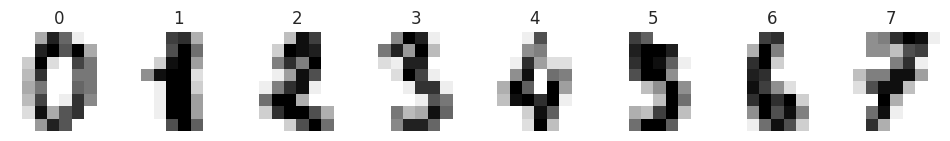

In [9]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()
print(digits.data.shape)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, label in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap="gray_r"); ax.set_title(label); ax.axis("off")
plt.show()

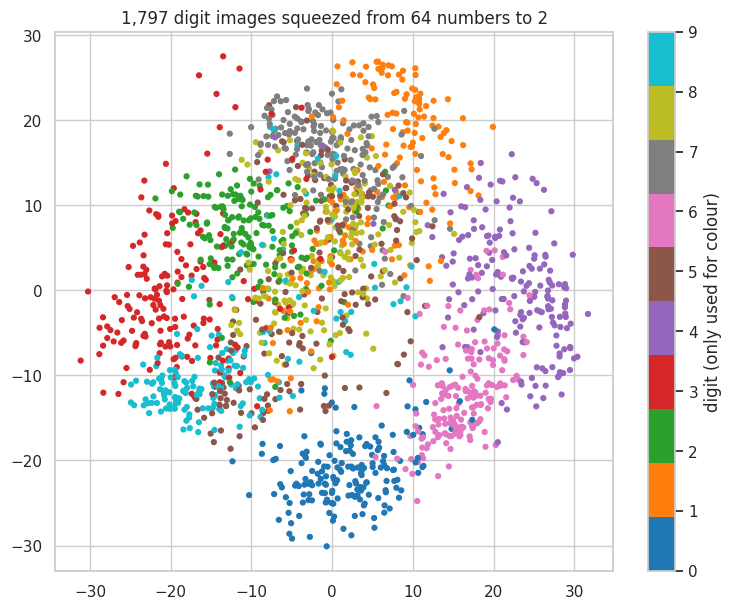

Information kept by 2 components: 28.5%


In [10]:
pca2 = PCA(n_components=2)
coords = pca2.fit_transform(digits.data)      # note: no labels used!

plt.figure(figsize=(9, 7))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=digits.target, cmap="tab10", s=12)
plt.colorbar(sc, label="digit (only used for colour)")
plt.title("1,797 digit images squeezed from 64 numbers to 2")
plt.show()

print(f"Information kept by 2 components: {pca2.explained_variance_ratio_.sum():.1%}")

🧠 PCA never saw the labels, yet many digits (0, 6, 4…) form their own clouds. Which digits overlap?

### 4.1 How many components do we need?

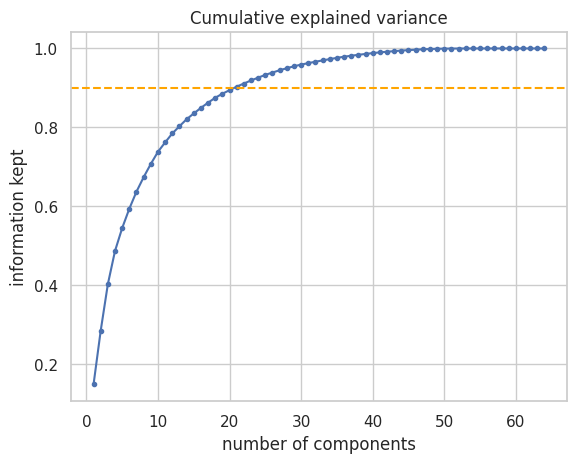

Components needed for 90%: 21


In [11]:
pca_all = PCA().fit(digits.data)
cumulative = np.cumsum(pca_all.explained_variance_ratio_)
plt.plot(range(1, 65), cumulative, marker=".")
plt.axhline(0.9, color="orange", linestyle="--")
plt.xlabel("number of components"); plt.ylabel("information kept")
plt.title("Cumulative explained variance")
plt.show()
print("Components needed for 90%:", int(np.argmax(cumulative >= 0.9)) + 1)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42, stratify=digits.target)

for n in [2, 10, 20]:
    m = make_pipeline(StandardScaler(), PCA(n_components=n), LogisticRegression(max_iter=5000)).fit(Xd_train, yd_train)
    print(f"{n:2d} components: accuracy {m.score(Xd_test, yd_test):.1%}")
m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xd_train, yd_train)
print(f"all 64 pixels: accuracy {m.score(Xd_test, yd_test):.1%}")

 2 components: accuracy 52.5%
10 components: accuracy 87.8%
20 components: accuracy 94.2%
all 64 pixels: accuracy 97.2%


---
## Part 5 · Anomaly detection: catch a faulty motor
We simulate sensor readings from a motor: **temperature** (°C) and **vibration** (mm/s). 480 readings are normal; 20 come from a **faulty** motor that runs a bit hotter and shakier. The algorithm is **not told** which are faulty.

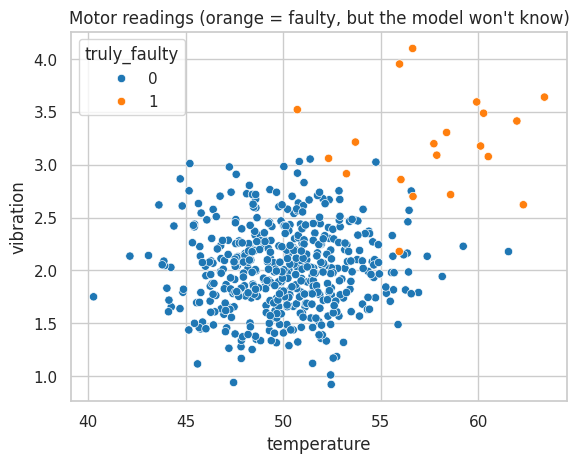

In [13]:
rng = np.random.RandomState(42)
normal = np.column_stack([rng.normal(50, 3, 480), rng.normal(2.0, 0.4, 480)])
faulty = np.column_stack([rng.normal(58, 3, 20), rng.normal(3.2, 0.5, 20)])

readings = pd.DataFrame(np.vstack([normal, faulty]), columns=["temperature", "vibration"])
readings["truly_faulty"] = [0] * 480 + [1] * 20

sns.scatterplot(data=readings, x="temperature", y="vibration", hue="truly_faulty", palette=["tab:blue", "tab:orange"])
plt.title("Motor readings (orange = faulty, but the model won't know)")
plt.show()

In [14]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.04, random_state=42)     # expect about 4% odd readings
readings["flagged"] = (iso.fit_predict(readings[["temperature", "vibration"]]) == -1).astype(int)

caught = ((readings.flagged == 1) & (readings.truly_faulty == 1)).sum()
false_alarms = ((readings.flagged == 1) & (readings.truly_faulty == 0)).sum()
missed = ((readings.flagged == 0) & (readings.truly_faulty == 1)).sum()
print(f"Flagged: {readings.flagged.sum()}  |  faults caught: {caught}/20  |  false alarms: {false_alarms}  |  missed: {missed}")

Flagged: 20  |  faults caught: 13/20  |  false alarms: 7  |  missed: 7


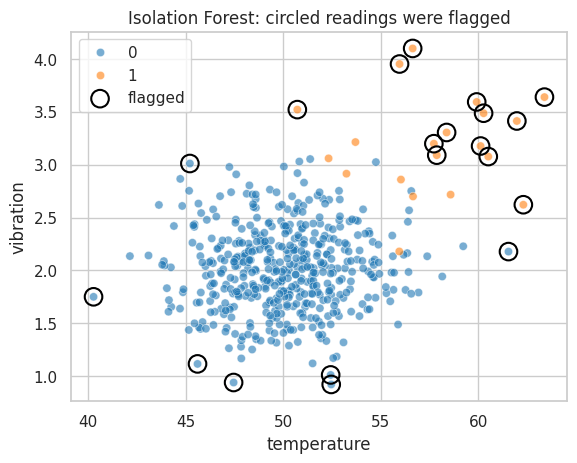

In [15]:
sns.scatterplot(data=readings, x="temperature", y="vibration", hue="truly_faulty", palette=["tab:blue", "tab:orange"], alpha=0.6)
flag = readings[readings.flagged == 1]
plt.scatter(flag.temperature, flag.vibration, facecolors="none", edgecolors="black", s=160, linewidths=1.5, label="flagged")
plt.legend()
plt.title("Isolation Forest: circled readings were flagged")
plt.show()

🧠 The false alarms are healthy readings at the **edge** of the normal cloud; the missed faults are hiding **inside** it. Real sensors are like this.

> ✍️ **Exercises**
> 1. Run K-Means on **three** columns: `Age`, `income`, `spending` (scale them first with `StandardScaler`). How do the groups change?
> 2. Change `contamination` to 0.02 and then 0.08. What happens to faults caught and false alarms?
> 3. Use PCA to draw the **breast cancer** data (30 columns) in 2D, coloured by diagnosis. *(Hint: scale first.)*

---
## 🎯 Recap
- **K-Means**: pick k (elbow/silhouette), assign → move → repeat. Humans name the groups.
- **Hierarchical**: a family tree you can cut at any height.
- **PCA**: keep the most information in fewer columns — for plots, speed and noise.
- **Isolation Forest**: odd readings are easy to isolate. Tune `contamination` for alarms vs misses.

---
## ✅ Solutions

In [ ]:
# Exercise 1
X3 = StandardScaler().fit_transform(mall[["Age", "income", "spending"]])
sils = {k: silhouette_score(X3, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X3)) for k in range(2, 11)}
best3 = max(sils, key=sils.get)
print("Best k with age included:", best3, f"(silhouette {sils[best3]:.3f})")
mall["cluster3"] = KMeans(n_clusters=best3, random_state=42, n_init=10).fit_predict(X3)
print(mall.groupby("cluster3")[["Age", "income", "spending"]].mean().round(1))

In [ ]:
# Exercise 2
for c in [0.02, 0.04, 0.08]:
    f = IsolationForest(contamination=c, random_state=42).fit_predict(readings[["temperature", "vibration"]]) == -1
    t = readings.truly_faulty == 1
    print(f"contamination {c}: caught {(f & t).sum()}/20, false alarms {(f & ~t).sum()}")

In [ ]:
# Exercise 3
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer()
bc2 = PCA(n_components=2).fit(StandardScaler().fit_transform(bc.data))
pts = bc2.transform(StandardScaler().fit_transform(bc.data))
sns.scatterplot(x=pts[:, 0], y=pts[:, 1], hue=pd.Series(bc.target).map({0: "malignant", 1: "benign"}), alpha=0.7)
plt.title(f"Breast cancer in 2D (keeps {bc2.explained_variance_ratio_.sum():.0%} of the information)")
plt.show()